 # **1.Import Libraries and Memory Settings**

In [12]:
import numpy as np
import matplotlib.pyplot as plt

den = np.load(r"/kaggle/input/datasets/mustafamathhar004/fsc-dataset/Supporters/Supporters/Images/200.npy")
print(f"Shape: {den.shape}")
print(f"Max value: {den.max():.6f}")
print(f"Sum (count): {den.sum():.1f}")

# إذا كانت القيم صغيرة جداً (مثل 0.001) → sigma كبير (15-20)
# إذا كانت القيم أكبر (مثل 1.0) → sigma صغير (4-8)

Shape: (533, 799)
Max value: 0.002220
Sum (count): 252.0


In [13]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
import random
import math
from scipy.ndimage import gaussian_filter

# Project paths
BASE       = Path(r"/kaggle/input/datasets/mustafamathhar004/fsc-dataset")
OUTPUT_DIR = Path("/kaggle/working/outputs_weather")
MODEL_DIR  = Path("/kaggle/working/models_weather")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

BATCH_SIZE  = 4
ACCUM_STEPS = 4      
NUM_WORKERS = 0      
PIN_MEMORY  = False  
#  ImageNet Normalization constants
IMG_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMG_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Training device: cpu


 # **2.Collect Image Paths**

In [14]:
def collect_samples(base_dir):
    samples = []

    def get_jpgs(folder):
        seen = set()
        result = []
        for ext in ["*.jpg", "*.jpeg", "*.JPG", "*.JPEG"]:
            for p in sorted(folder.glob(ext)):
                if p.stem not in seen:
                    seen.add(p.stem)
                    result.append(p)
        return result

    # Supporters
    for jpg in get_jpgs(base_dir / "Supporters/Supporters" / "Images"):
        npy = jpg.with_suffix('.npy')
        if npy.exists():
            samples.append((jpg, npy))

    # Supporters-Team
    teams_dir = base_dir / "Supporters-Team/Supporters-Team" / "Images"
    if teams_dir.exists():
        for team_folder in sorted(teams_dir.iterdir()):
            if not team_folder.is_dir():
                continue
            for jpg in get_jpgs(team_folder):
                npy = jpg.with_suffix('.npy')
                if npy.exists():
                    samples.append((jpg, npy))

    # Empty_scenes
    empty_dir = base_dir / "Empty_scenes/Empty_scenes" / "Images"
    if empty_dir.exists():
        for jpg in get_jpgs(empty_dir):
            npy = jpg.with_suffix('.npy')
            if npy.exists():
                samples.append((jpg, npy))

    return samples

 # **3.Data Inspection**

In [15]:
all_samples = collect_samples(BASE)
print(f"Total samples: {len(all_samples)}")

counts = []
zero_maps = 0
for img_path, npy_path in all_samples[:50]:
    den = np.load(str(npy_path)).astype(np.float32)
    total = den.sum()
    counts.append(total)
    if total < 1.0:
        zero_maps += 1

counts = np.array(counts)
print(f"\nCount statistics (first 50 samples):")
print(f"   Mean : {counts.mean():.1f}")
print(f"   min  : {counts.min():.1f} | max: {counts.max():.1f}")
print(f"   Empty maps (< 1): {zero_maps}/50  ← normal (Empty_scenes)")


Total samples: 4087

Count statistics (first 50 samples):
   Mean : 194.6
   min  : 12.0 | max: 804.0
   Empty maps (< 1): 0/50  ← normal (Empty_scenes)


# **4. Augmentation + Dataset**

In [16]:
class SimpleAugmentation:
    def __call__(self, img):
        if random.random() < 0.3:
            alpha = random.uniform(0.8, 1.2)
            beta  = random.uniform(-20, 20)
            img   = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        return img

class CrowdDataset(Dataset):
    def __init__(self, samples, augment=True, target_size=(512, 512), density_size=(64, 64)):
        self.samples  = samples
        self.augment  = augment
        self.target_h, self.target_w   = target_size
        self.density_h, self.density_w = density_size
        assert self.target_h // 2 == self.density_h and self.target_w // 2 == self.density_w
        self.aug = WeatherAugmentation() if augment else None

        # ImageNet stats (shared across train/val/test)
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        print(f"Number of samples: {len(self.samples)} (augment: {augment})")

    def __len__(self):
        return len(self.samples)

    def _resize_density_map(self, den, total_count):
        if den.shape[0] > self.density_h:
            den = cv2.GaussianBlur(den, (3, 3), 0.5)
        den_resized = cv2.resize(den, (self.density_w, self.density_h),
                                 interpolation=cv2.INTER_AREA)
        sum_resized = den_resized.sum()
        if sum_resized > 1e-6:
            den_resized = den_resized * (total_count / sum_resized)
        else:
            den_resized = np.zeros((self.density_h, self.density_w), dtype=np.float32)
        return den_resized

    def __getitem__(self, idx):
        jpg_path, npy_path = self.samples[idx]

        img = cv2.imread(str(jpg_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.target_w, self.target_h), interpolation=cv2.INTER_LINEAR)
        if self.augment and self.aug:
            img = self.aug(img)

        # Normalize after conversion to float
        img = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        img = (img - self.mean) / self.std

        den = np.load(str(npy_path)).astype(np.float32)
        total_count = float(den.sum())
        den_resized = self._resize_density_map(den, total_count)
        den_tensor  = torch.from_numpy(den_resized).unsqueeze(0)

        return img, den_tensor

In [18]:
def add_fog(image, fog_intensity=0.5):
    """إضافة ضباب إلى الصورة"""
    img_fog = image.copy().astype(np.float32)
    fog = np.ones_like(img_fog) * fog_intensity * 255
 
    img_fog = cv2.addWeighted(img_fog, 1 - fog_intensity, fog, fog_intensity, 0)
    return np.clip(img_fog, 0, 255).astype(np.uint8)

def add_night_effect(image, dark_factor=0.6):
    """محاكاة ظروف الليل: تعتيم وزيادة التباين البارد"""
    img_night = image.copy().astype(np.float32)
    img_night = img_night * dark_factor
  
    img_night[:, :, 0] = img_night[:, :, 0] * 0.8   # Red
    img_night[:, :, 1] = img_night[:, :, 1] * 0.9   # Green
    img_night[:, :, 2] = img_night[:, :, 2] * 1.2   # Blue
    return np.clip(img_night, 0, 255).astype(np.uint8)

def add_rain(image, intensity=0.3):
    """إضافة تأثير مطر بخطوط عشوائية"""
    img_rain = image.copy()
   
    num_drops = int(img_rain.shape[0] * img_rain.shape[1] * intensity * 0.01)
    for _ in range(num_drops):
        x = random.randint(0, img_rain.shape[1] - 1)
        y = random.randint(0, img_rain.shape[0] - 1)
        length = random.randint(5, 15)
        angle = random.uniform(20, 30)  
        x_end = int(x + length * np.cos(np.radians(angle)))
        y_end = int(y + length * np.sin(np.radians(angle)))
        cv2.line(img_rain, (x, y), (x_end, y_end), (180, 180, 200), 1)
    return img_rain

class WeatherAugmentation:
    def __call__(self, img):
        weather_type = random.choice(['none', 'rain', 'night', 'fog'])
        if weather_type == 'rain' and random.random() < 0.3:
            img = add_rain(img, intensity=random.uniform(0.2, 0.5))
        elif weather_type == 'night' and random.random() < 0.3:
            img = add_night_effect(img, dark_factor=random.uniform(0.4, 0.7))
        elif weather_type == 'fog' and random.random() < 0.3:
            img = add_fog(img, fog_intensity=random.uniform(0.3, 0.6))
        if random.random() < 0.3:
            alpha = random.uniform(0.8, 1.2)
            beta = random.uniform(-20, 20)
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        return img

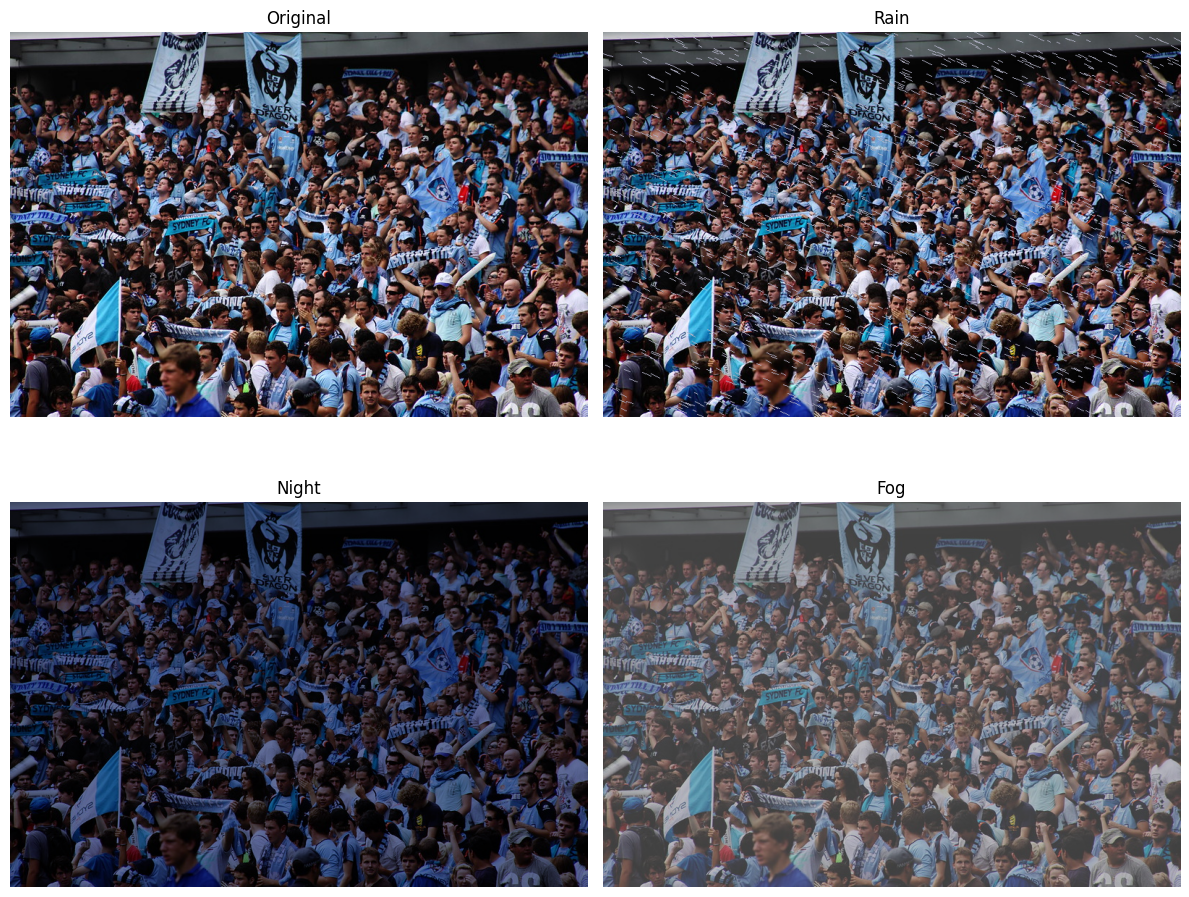

In [20]:
import matplotlib.pyplot as plt

# دالة لعرض تأثيرات الطقس على صورة واحدة
def visualize_weather_effects(image_path, save_path=None):
    # قراءة الصورة
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # تطبيق التأثيرات
    img_rain = add_rain(img.copy(), intensity=0.4)
    img_night = add_night_effect(img.copy(), dark_factor=0.5)
    img_fog = add_fog(img.copy(), fog_intensity=0.5)
    
    # عرض النتائج
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_rain)
    axes[0, 1].set_title("Rain")
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(img_night)
    axes[1, 0].set_title("Night")
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(img_fog)
    axes[1, 1].set_title("Fog")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

# استخدام المثال على أول صورة في مجموعة البيانات
# بعد تحميل العينات (all_samples)، يمكنك اختيار صورة عشوائية
sample_img_path, _ = all_samples[0]  # أول صورة
visualize_weather_effects(str(sample_img_path), save_path="/kaggle/working/weather_effects_example.png")

# **5. CSRNet with U-Net Decoder**

In [6]:
class DoubleConv(nn.Module):
    """Double Conv-BN-ReLU block (U-Net building block)"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class CSRNetUNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        feats = list(vgg.features.children())

        # Encoder (from VGG16)
        self.enc1 = nn.Sequential(*feats[0:4])   # 512x512 → 512x512, 64ch
        self.enc2 = nn.Sequential(*feats[4:9])   # → 256x256, 128ch
        self.enc3 = nn.Sequential(*feats[9:16])  # → 128x128, 256ch
        self.enc4 = nn.Sequential(*feats[16:23]) # → 64x64,   512ch

        # Bottleneck (dilated)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
        )

        # Decoder (U-Net style – up to 256x256)
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1 = DoubleConv(512 + 256, 256)   # 512(e4) + 256(e3) → 256

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = DoubleConv(256 + 128, 128)   # 256(dec1) + 128(enc2) → 128

        # Output head (operates at 256x256)
        self.head = nn.Sequential(
            nn.Conv2d(128, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1),
        )
        nn.init.normal_(self.head[-1].weight, std=0.01)
        nn.init.constant_(self.head[-1].bias, 0.0)

    def forward(self, x):
        e1 = self.enc1(x)      # 64ch,  512x512
        e2 = self.enc2(e1)     # 128ch, 256x256
        e3 = self.enc3(e2)     # 256ch, 128x128
        e4 = self.enc4(e3)     # 512ch, 64x64

        b = self.bottleneck(e4)  # 512ch, 64x64

        d1 = self.dec1(torch.cat([self.up1(b), e3], dim=1))   # 256ch, 128x128
        d2 = self.dec2(torch.cat([self.up2(d1), e2], dim=1))   # 128ch, 256x256

        out = self.head(d2)     # 1ch, 256x256
        return torch.clamp(out, min=0)


DENSITY_SIZE = (256, 256)  
TARGET_SIZE  = (512, 512)


# **6. Combined Loss Function**

In [7]:
class CombinedLoss(nn.Module):
    def __init__(self, count_weight=0.01):
        super().__init__()
        self.mse          = nn.MSELoss()
        self.count_weight = count_weight

    def forward(self, pred, target):
        density_loss = self.mse(pred, target)
        pred_count   = pred.sum(dim=(1, 2, 3))
        true_count   = target.sum(dim=(1, 2, 3))
        count_loss   = self.mse(pred_count, true_count)
        return density_loss + self.count_weight * count_loss

# **7. Training and Evaluation Functions**

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, accum_steps):
    model.train()
    optimizer.zero_grad()
    total_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for i, (imgs, dens) in enumerate(loop):
        imgs, dens = imgs.to(device), dens.to(device)
        pred = model(imgs)
        loss = criterion(pred, dens) / accum_steps
        loss.backward()

        if (i + 1) % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps
        loop.set_postfix(loss=total_loss / (i + 1))

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    mae = mse = 0.0
    for imgs, dens in loader:
        imgs, dens  = imgs.to(device), dens.to(device)
        pred        = model(imgs)
        pred_cnt    = pred.sum(dim=(1, 2, 3))
        true_cnt    = dens.sum(dim=(1, 2, 3))
        mae        += torch.abs(pred_cnt - true_cnt).sum().item()
        mse        += ((pred_cnt - true_cnt) ** 2).sum().item()
    n = len(loader.dataset)
    return mae / n, np.sqrt(mse / n)

# **8. Prepare DataLoaders**

In [8]:
random.seed(42)
random.shuffle(all_samples)

test_size  = int(len(all_samples) * 0.10)
val_size   = int(len(all_samples) * 0.10)
train_size = len(all_samples) - val_size - test_size

train_samples = all_samples[:train_size]
val_samples   = all_samples[train_size : train_size + val_size]
test_samples  = all_samples[train_size + val_size:]

# Use the updated DENSITY_SIZE (256x256)
train_ds = CrowdDataset(train_samples, augment=True,  target_size=TARGET_SIZE, density_size=DENSITY_SIZE)
val_ds   = CrowdDataset(val_samples,   augment=False, target_size=TARGET_SIZE, density_size=DENSITY_SIZE)
test_ds  = CrowdDataset(test_samples,  augment=False, target_size=TARGET_SIZE, density_size=DENSITY_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Training: {len(train_ds)} | Validation: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Number of samples: 3271 (augment: True)
Number of samples: 408 (augment: False)
Number of samples: 408 (augment: False)
Training: 3271 | Validation: 408 | Test: 408
Effective batch size: 16


# **9. Initialize Model and Optimizer**

In [9]:
model = CSRNetUNet().to(device)

# Differential LR: backbone slower than decoder
encoder_params = list(model.enc1.parameters()) + list(model.enc2.parameters()) + \
                 list(model.enc3.parameters()) + list(model.enc4.parameters())
decoder_params = list(model.bottleneck.parameters()) + \
                 list(model.dec1.parameters()) + \
                 list(model.dec2.parameters()) + \
                 list(model.head.parameters())

optimizer = optim.AdamW(
    [
        {"params": encoder_params, "lr": 1e-5},
        {"params": decoder_params, "lr": 1e-4},
    ],
    weight_decay=1e-4
)

criterion = CombinedLoss(count_weight=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-6)

print("Model ready for training")
print(f"   Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Check output size
with torch.no_grad():
    dummy = torch.zeros(1, 3, 512, 512).to(device)
    out   = model(dummy)
    print(f"   Model output shape: {tuple(out.shape)}  ← should be (1, 1, 256, 256)")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 193MB/s] 


Model ready for training
   Number of parameters: 17,702,273
   Model output shape: (1, 1, 256, 256)  ← should be (1, 1, 256, 256)


# **10. Training Loop**

In [ ]:
best_mae         = float('inf')
patience_counter = 0
history          = {"train_loss": [], "val_mae": [], "val_rmse": []}

EPOCHS   = 80
PATIENCE = 15

print("Starting training...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss        = train_one_epoch(model, train_loader, optimizer, criterion, ACCUM_STEPS)
    val_mae, val_rmse = evaluate(model, val_loader, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_mae"].append(val_mae)
    history["val_rmse"].append(val_rmse)

    lr = optimizer.param_groups[1]['lr']
    print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | MAE: {val_mae:.2f} | RMSE: {val_rmse:.2f} | LR: {lr:.2e}")

    if val_mae < best_mae:
        best_mae = val_mae
        torch.save(model.state_dict(), MODEL_DIR / "best_model.pth")
        print(f"   ✓ Best model saved (MAE={best_mae:.2f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"⏹️ Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        with open(OUTPUT_DIR / "history.json", "w") as f:
            json.dump(history, f, indent=2)

# **11. Plot Training Curves**

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", color="royalblue")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training Loss")
plt.grid(alpha=0.3); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_mae"],  label="MAE",  color="tomato")
plt.plot(history["val_rmse"], label="RMSE", color="orange")
plt.xlabel("Epoch"); plt.ylabel("Persons"); plt.title("Validation Metrics")
plt.grid(alpha=0.3); plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()
print(f"Plot saved to: {OUTPUT_DIR / 'training_curves.png'}")

# **12. Final Evaluation on Test Set**

In [ ]:
model.load_state_dict(torch.load(MODEL_DIR / "best_model.pth", map_location=device))
test_mae, test_rmse = evaluate(model, test_loader, device)

print(f"\nFinal results on Test Set:")
print(f"   MAE  = {test_mae:.2f}")
print(f"   RMSE = {test_rmse:.2f}")

with open(OUTPUT_DIR / "test_results.json", "w") as f:
    json.dump({"test_mae": test_mae, "test_rmse": test_rmse,
               "best_val_mae": best_mae}, f, indent=2)

print(f"\nTraining completed")
print(f"   Best MAE on Validation : {best_mae:.2f}")
print(f"   Model saved at          : {MODEL_DIR / 'best_model.pth'}")

# **13. Visual Comparison with Smoothed Predicted Map**

In [ ]:
def denormalize(img_tensor):
    """Return image to [0,1] range after ImageNet normalization for display"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

def visualize_smoothed_comparison(model, dataset, device,
                                   num_samples=5, sigma_smooth=1.5, save_dir=None):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    for idx, sample_idx in enumerate(indices):
        img, true_density = dataset[sample_idx]
        true_count = true_density.sum().item()

        img_batch = img.unsqueeze(0).to(device)
        with torch.no_grad():
            pred_density = model(img_batch).cpu().squeeze(0).squeeze(0).numpy()

        # Smooth map while preserving sum
        pred_smoothed = gaussian_filter(pred_density, sigma=sigma_smooth)
        sum_orig   = pred_density.sum()
        sum_smooth = pred_smoothed.sum()
        if sum_smooth > 1e-6:
            pred_smoothed = pred_smoothed * (sum_orig / sum_smooth)
        pred_count_smoothed = pred_smoothed.sum()

        # Denormalize before display
        img_np = denormalize(img).permute(1, 2, 0).numpy()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(img_np)
        axes[0].set_title("Original Image", fontsize=12)
        axes[0].axis('off')

        im1 = axes[1].imshow(true_density.squeeze().numpy(), cmap='hot')
        axes[1].set_title(f"True Density (sum = {true_count:.1f})", fontsize=12)
        plt.colorbar(im1, ax=axes[1], fraction=0.046)

        im2 = axes[2].imshow(pred_smoothed, cmap='hot')
        axes[2].set_title(f"Smoothed Predicted (σ={sigma_smooth}, sum = {pred_count_smoothed:.1f})", fontsize=12)
        plt.colorbar(im2, ax=axes[2], fraction=0.046)

        plt.tight_layout()
        if save_dir:
            Path(save_dir).mkdir(parents=True, exist_ok=True)
            plt.savefig(f"{save_dir}/smoothed_comp_{idx}.png", dpi=150)
        plt.show()

    print(f"Displayed {len(indices)} comparisons (sigma={sigma_smooth}).")

print("\nDisplaying comparisons between true and predicted densities:\n")
visualize_smoothed_comparison(model, test_ds, device, num_samples=5, sigma_smooth=1.5,
                               save_dir=str(OUTPUT_DIR / "comparisons"))

# **Final Model Test on Test Set (same split as training)**

In [ ]:
import torch
import numpy as np
import cv2
import random
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torch.nn as nn
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import json

# ---------------------- 1. Define paths --------------------------
BASE_DATA = Path("/kaggle/input/datasets/mustafamathhar004/fsc-dataset")
MODEL_PATH = "/kaggle/input/datasets/mustafamathhar004/fsc-model-and-training/models_weather/best_model.pth"

# ---------------------- 2. Sample collection functions (matching structure) ---
def get_jpgs(folder):
    seen = set()
    result = []
    for ext in ["*.jpg", "*.jpeg", "*.JPG", "*.JPEG"]:
        for p in sorted(folder.glob(ext)):
            if p.stem not in seen:
                seen.add(p.stem)
                result.append(p)
    return result

def collect_samples(base_dir):
    samples = []
    # Supporters
    supporters_img_dir = base_dir / "Supporters/Supporters" / "Images"
    if supporters_img_dir.exists():
        for jpg in get_jpgs(supporters_img_dir):
            npy = jpg.with_suffix('.npy')
            if npy.exists():
                samples.append((jpg, npy))
    # Supporters-Team
    teams_dir = base_dir / "Supporters-Team/Supporters-Team" / "Images"
    if teams_dir.exists():
        for team_folder in sorted(teams_dir.iterdir()):
            if not team_folder.is_dir():
                continue
            for jpg in get_jpgs(team_folder):
                npy = jpg.with_suffix('.npy')
                if npy.exists():
                    samples.append((jpg, npy))
    # Empty_scenes
    empty_dir = base_dir / "Empty_scenes/Empty_scenes" / "Images"
    if empty_dir.exists():
        for jpg in get_jpgs(empty_dir):
            npy = jpg.with_suffix('.npy')
            if npy.exists():
                samples.append((jpg, npy))
    return samples

# ---------------------- 3. Dataset definition (same as used) ------------
class SimpleAugmentation:
    def __call__(self, img):
        if random.random() < 0.3:
            alpha = random.uniform(0.8, 1.2)
            beta  = random.uniform(-20, 20)
            img   = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
        return img

class CrowdDataset(Dataset):
    def __init__(self, samples, augment=False, target_size=(512, 512), density_size=(256, 256)):
        self.samples = samples
        self.augment = augment
        self.target_h, self.target_w = target_size
        self.density_h, self.density_w = density_size
        assert self.target_h // 2 == self.density_h and self.target_w // 2 == self.density_w
        self.aug = SimpleAugmentation() if augment else None
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.samples)

    def _resize_density_map(self, den, total_count):
        if den.shape[0] > self.density_h:
            den = cv2.GaussianBlur(den, (3, 3), 0.5)
        den_resized = cv2.resize(den, (self.density_w, self.density_h), interpolation=cv2.INTER_AREA)
        sum_resized = den_resized.sum()
        if sum_resized > 1e-6:
            den_resized = den_resized * (total_count / sum_resized)
        else:
            den_resized = np.zeros((self.density_h, self.density_w), dtype=np.float32)
        return den_resized

    def __getitem__(self, idx):
        jpg_path, npy_path = self.samples[idx]
        img = cv2.imread(str(jpg_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.target_w, self.target_h), interpolation=cv2.INTER_LINEAR)
        if self.augment and self.aug:
            img = self.aug(img)
        img = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        img = (img - self.mean) / self.std
        den = np.load(str(npy_path)).astype(np.float32)
        total_count = float(den.sum())
        den_resized = self._resize_density_map(den, total_count)
        den_tensor = torch.from_numpy(den_resized).unsqueeze(0)
        return img, den_tensor

# ---------------------- 4. Model definition (CSRNetUNet with 256x256 output) --
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class CSRNetUNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        feats = list(vgg.features.children())
        self.enc1 = nn.Sequential(*feats[0:4])
        self.enc2 = nn.Sequential(*feats[4:9])
        self.enc3 = nn.Sequential(*feats[9:16])
        self.enc4 = nn.Sequential(*feats[16:23])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, dilation=2, padding=2), nn.ReLU(inplace=True),
        )
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1 = DoubleConv(512 + 256, 256)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = DoubleConv(256 + 128, 128)
        self.head = nn.Sequential(
            nn.Conv2d(128, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1),
        )
        nn.init.normal_(self.head[-1].weight, std=0.01)
        nn.init.constant_(self.head[-1].bias, 0.0)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        d1 = self.dec1(torch.cat([self.up1(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d1), e2], dim=1))
        out = self.head(d2)
        return torch.clamp(out, min=0)

# ---------------------- 5. Collect and split samples -------------------
all_samples = collect_samples(BASE_DATA)
print(f"Total samples: {len(all_samples)}")

random.seed(42)
random.shuffle(all_samples)

test_size  = int(len(all_samples) * 0.10)
val_size   = int(len(all_samples) * 0.10)
train_size = len(all_samples) - val_size - test_size

train_samples = all_samples[:train_size]
val_samples   = all_samples[train_size:train_size+val_size]
test_samples  = all_samples[train_size+val_size:]

print(f"Training: {len(train_samples)} | Validation: {len(val_samples)} | Test: {len(test_samples)}")

# ---------------------- 6. Create DataLoader for test ----------------
BATCH_SIZE = 4
NUM_WORKERS = 0
PIN_MEMORY = False

test_ds = CrowdDataset(test_samples, augment=False, target_size=(512,512), density_size=(256,256))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# ---------------------- 7. Load model ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CSRNetUNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Model loaded from {MODEL_PATH}")

# ---------------------- 8. Evaluation function ----------------------------
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    mae = mse = 0.0
    for imgs, dens in loader:
        imgs, dens = imgs.to(device), dens.to(device)
        pred = model(imgs)
        pred_cnt = pred.sum(dim=(1,2,3))
        true_cnt = dens.sum(dim=(1,2,3))
        mae += torch.abs(pred_cnt - true_cnt).sum().item()
        mse += ((pred_cnt - true_cnt) ** 2).sum().item()
    n = len(loader.dataset)
    return mae / n, np.sqrt(mse / n)

# ---------------------- 9. Final evaluation ----------------------------
test_mae, test_rmse = evaluate(model, test_loader, device)
print(f"\nFinal results on Test Set:")
print(f"   MAE  = {test_mae:.2f}")
print(f"   RMSE = {test_rmse:.2f}")

# Save results (optional)
with open("/kaggle/working/test_results_final.json", "w") as f:
    json.dump({"test_mae": test_mae, "test_rmse": test_rmse}, f, indent=2)

# ---------------------- 10. Show random test samples --------------------------
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

def visualize_samples(model, dataset, device, num_samples=3):
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    for idx in indices:
        img, true_density = dataset[idx]
        true_count = true_density.sum().item()
        img_batch = img.unsqueeze(0).to(device)
        with torch.no_grad():
            pred_density = model(img_batch).cpu().squeeze(0).squeeze(0).numpy()
        # Light smoothing
        pred_smoothed = gaussian_filter(pred_density, sigma=1.0)
        pred_smoothed = pred_smoothed * (pred_density.sum() / (pred_smoothed.sum() + 1e-6))
        
        img_np = denormalize(img).permute(1,2,0).numpy()
        fig, axes = plt.subplots(1,3, figsize=(15,5))
        axes[0].imshow(img_np)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        axes[1].imshow(true_density.squeeze().numpy(), cmap='hot')
        axes[1].set_title(f"True Density (count={true_count:.1f})")
        plt.colorbar(axes[1].imshow(true_density.squeeze().numpy(), cmap='hot'), ax=axes[1], fraction=0.046)
        axes[2].imshow(pred_smoothed, cmap='hot')
        axes[2].set_title(f"Predicted (smoothed, count={pred_smoothed.sum():.1f})")
        plt.colorbar(axes[2].imshow(pred_smoothed, cmap='hot'), ax=axes[2], fraction=0.046)
        plt.tight_layout()
        plt.show()

print("\nDisplaying random test samples:")
visualize_samples(model, test_ds, device, num_samples=3)

print("Testing completed.")

Total samples: 4087
Training: 3271 | Validation: 408 | Test: 408
Model loaded from /kaggle/input/datasets/mustafamathhar004/fsc-model-and-training/models_weather/best_model.pth


# **Display visual comparisons of heatmaps.**

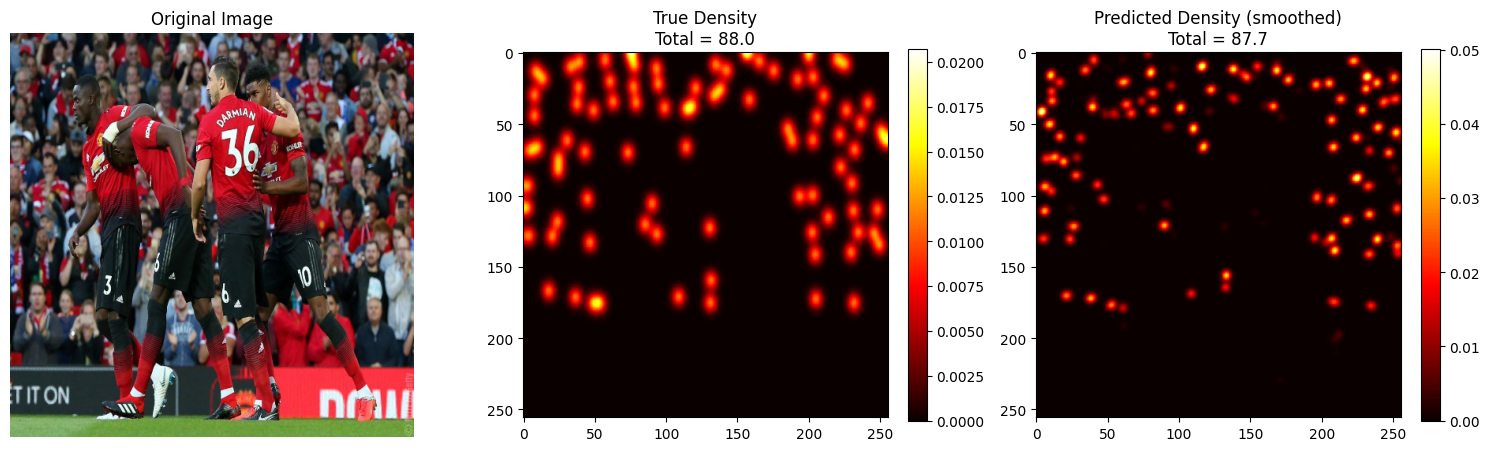

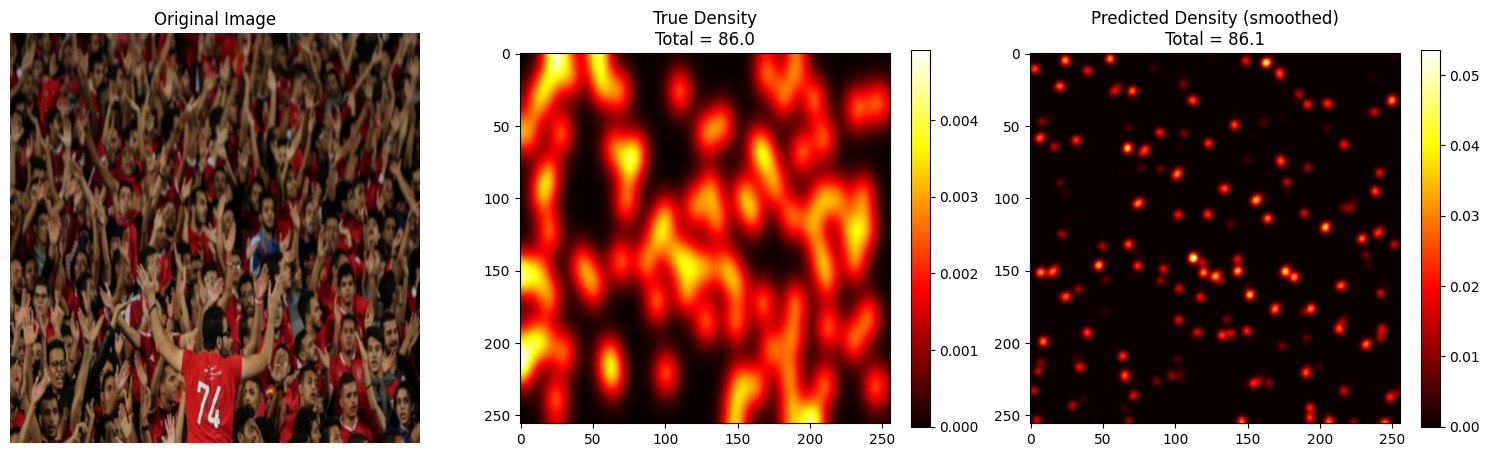

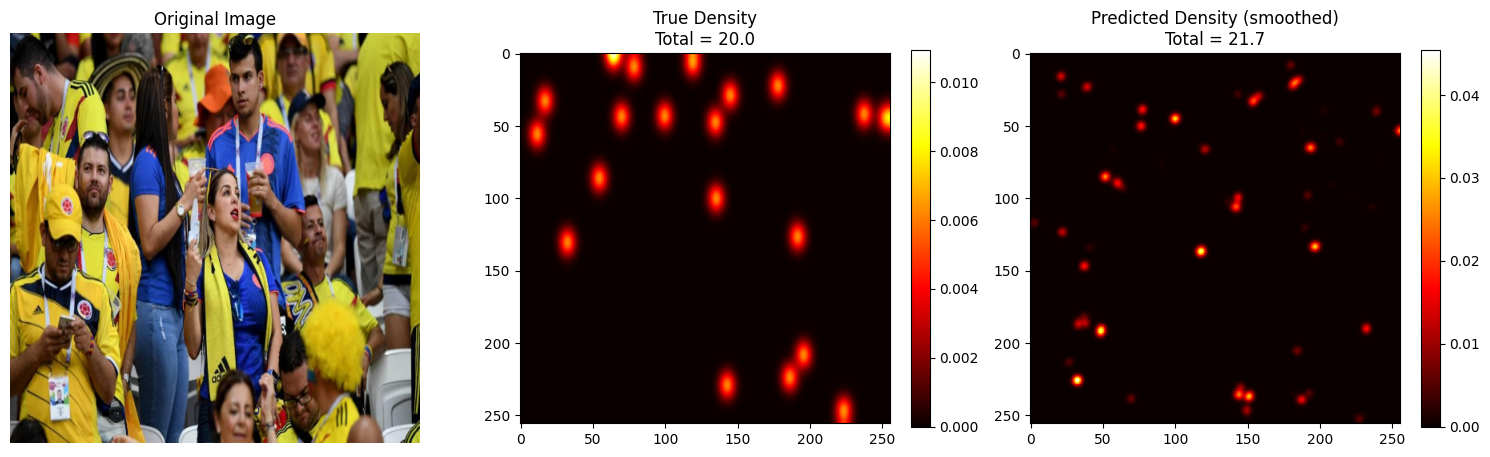

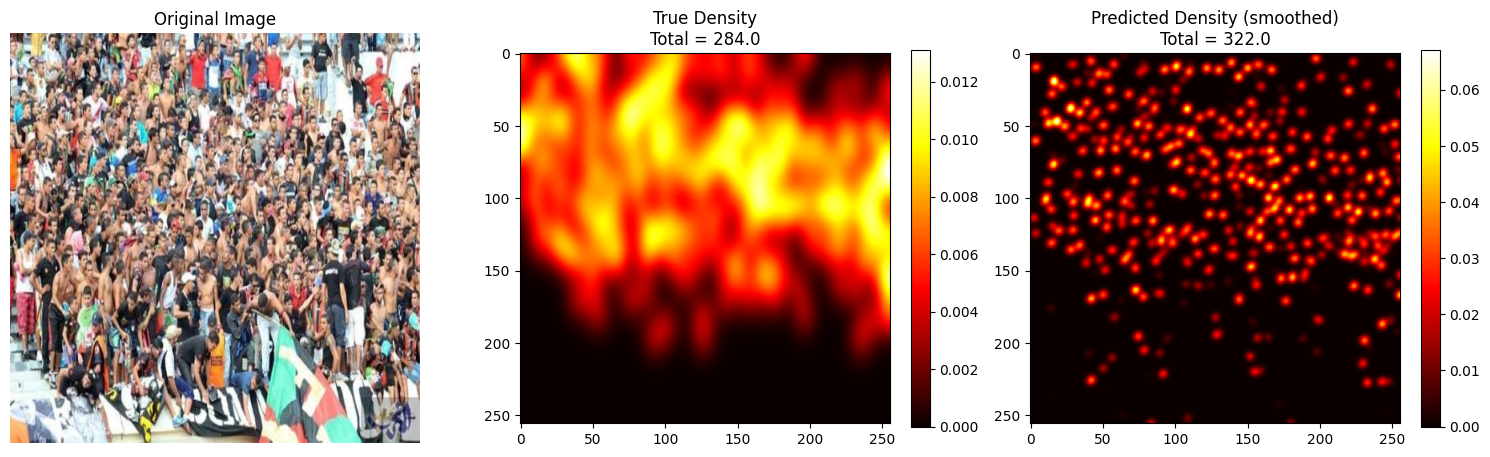

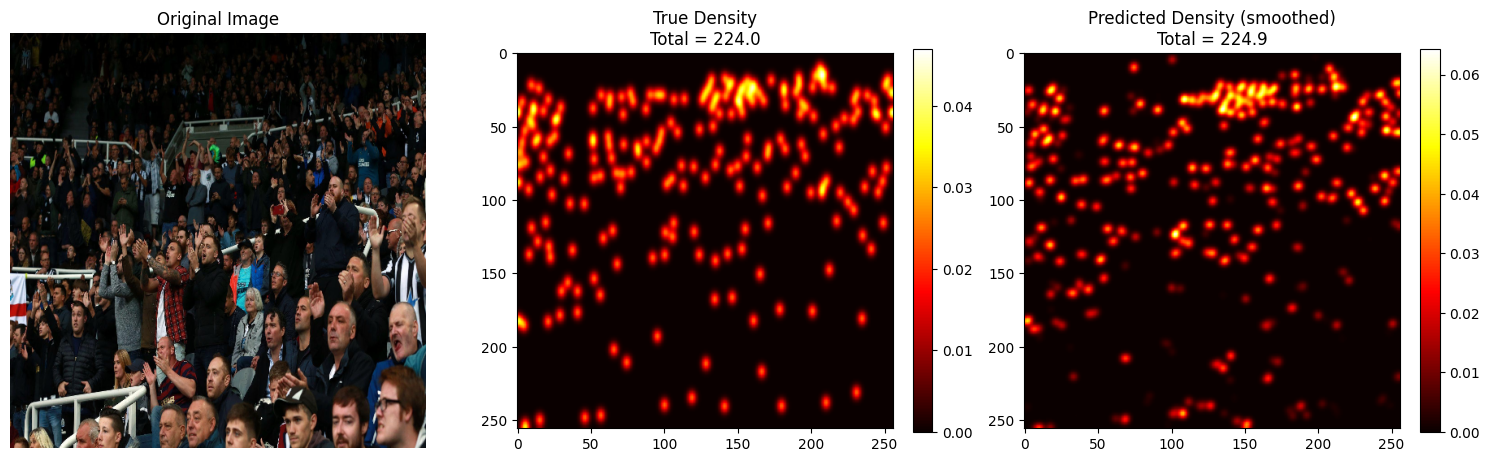

In [21]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import random

def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

model.eval()
indices = random.sample(range(len(test_ds)), min(5, len(test_ds)))

for i, idx in enumerate(indices):
    img, true_density = test_ds[idx]
    true_count = true_density.sum().item()
    
    img_batch = img.unsqueeze(0).to(device)
    with torch.no_grad():
        pred_density = model(img_batch).cpu().squeeze(0).squeeze(0).numpy()
    
    # تنعيم الخريطة المتوقعة لمظهر أفضل
    pred_smoothed = gaussian_filter(pred_density, sigma=2.0)
    # الحفاظ على المجموع
    pred_smoothed = pred_smoothed * (pred_density.sum() / (pred_smoothed.sum() + 1e-8))
    
    img_np = denormalize(img).permute(1,2,0).numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_np)
    axes[0].set_title(f"Original Image")
    axes[0].axis('off')
    
    im1 = axes[1].imshow(true_density.squeeze().numpy(), cmap='hot')
    axes[1].set_title(f"True Density\nTotal = {true_count:.1f}")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    im2 = axes[2].imshow(pred_smoothed, cmap='hot')
    axes[2].set_title(f"Predicted Density (smoothed)\nTotal = {pred_smoothed.sum():.1f}")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    plt.tight_layout()
    plt.show()

# **Plot MAE & RMSE curves from saved training history**

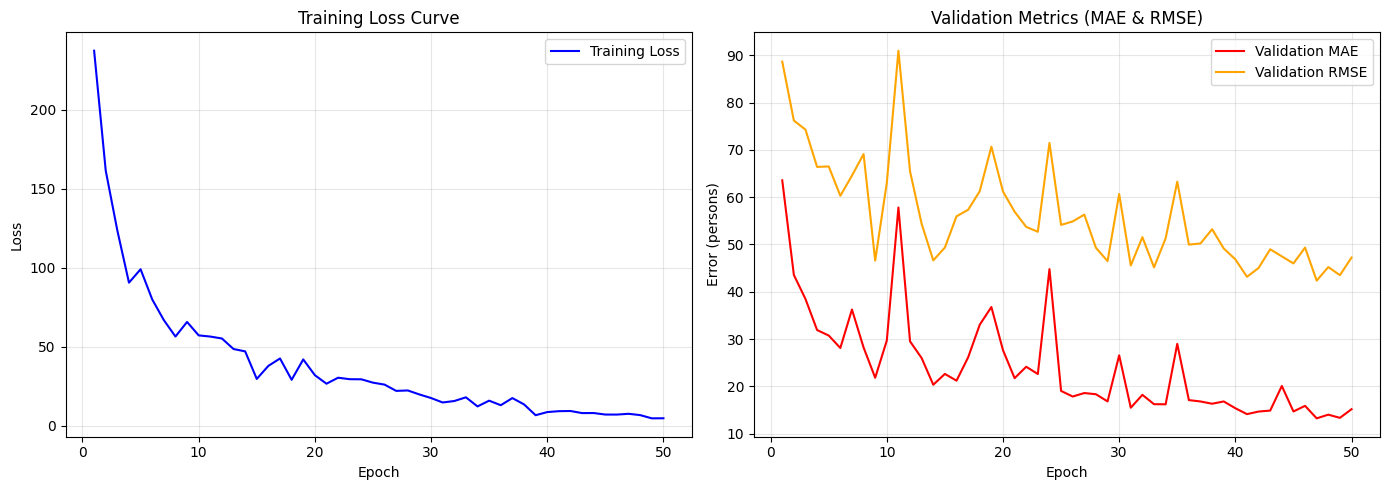

Best validation MAE  = 13.2346 persons
Best validation RMSE = 42.3517 persons
Final epoch MAE  = 15.1674
Final epoch RMSE = 47.2342


In [22]:

import json
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your history.json file (adjust if needed)
# It was saved during training under OUTPUT_DIR / "history.json"
history_path = Path("/kaggle/working/outputs_weather/history.json")

# If the file is not there, try to locate it from your model directory
if not history_path.exists():
    # Alternative: look in the directory where you saved the model
    history_path = Path("/kaggle/input/datasets/mustafamathhar004/fsc-model-and-training/outputs_weather/history.json")

# Load the history
with open(history_path, "r") as f:
    history = json.load(f)

# Extract data 
train_loss = history["train_loss"]
val_mae    = history["val_mae"]
val_rmse   = history["val_rmse"]
epochs = range(1, len(train_loss) + 1)

# Create figure
plt.figure(figsize=(14, 5))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Validation MAE & RMSE
plt.subplot(1, 2, 2)
plt.plot(epochs, val_mae, 'r-', label='Validation MAE')
plt.plot(epochs, val_rmse, 'orange', label='Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('Error (persons)')
plt.title('Validation Metrics (MAE & RMSE)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.pdf", dpi=150)   
plt.show()

# Print final validation MAE and RMSE 
print(f"Best validation MAE  = {min(val_mae):.4f} persons")
print(f"Best validation RMSE = {min(val_rmse):.4f} persons")
print(f"Final epoch MAE  = {val_mae[-1]:.4f}")
print(f"Final epoch RMSE = {val_rmse[-1]:.4f}")